In [2]:
import pandas as pd
import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from tkinter import Tk, filedialog, TclError
import os


/home/jetson/Desktop/SqueakView/.venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/jetson/Desktop/SqueakView/.venv/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/jetson/Desktop/SqueakView/.venv/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the s

### Load Detections csv

In [4]:
# Path to your detections CSV (DeepStream/SqueakView current schema)
# TODO: replace with a file picker if preferred
csv_path = "/home/jetson/Desktop/SqueakView/runs/test1_2026-02-24_08-40-02/detections.csv"

detections = pd.read_csv(csv_path)

required_cols = {"frame", "ts_us", "conf", "x", "y", "w", "h"}
missing = required_cols - set(detections.columns)
if missing:
    raise ValueError(f"Detections CSV missing required columns: {sorted(missing)}")

# Optional for multi-camera files: set to e.g. 'cam0' or 'cam1'
analysis_source = None
if "source" in detections.columns:
    print("Available sources:", sorted(detections["source"].dropna().unique().tolist()))
    if analysis_source:
        detections = detections[detections["source"] == analysis_source].copy()
        print(f"Filtered to source={analysis_source}, rows={len(detections)}")

# Derived analysis fields from current schema
# x,y,w,h are top-left + size in pixels
# ts_s is wall-clock seconds derived from ts_us

detections["frame"] = pd.to_numeric(detections["frame"], errors="coerce")
detections["ts_us"] = pd.to_numeric(detections["ts_us"], errors="coerce")
detections["conf"] = pd.to_numeric(detections["conf"], errors="coerce")
for c in ["x", "y", "w", "h"]:
    detections[c] = pd.to_numeric(detections[c], errors="coerce")

detections["ts_s"] = detections["ts_us"] / 1_000_000.0
detections["x1"] = detections["x"]
detections["y1"] = detections["y"]
detections["x2"] = detections["x"] + detections["w"]
detections["y2"] = detections["y"] + detections["h"]
detections["cx"] = detections["x"] + (detections["w"] / 2.0)
detections["cy"] = detections["y"] + (detections["h"] / 2.0)

# Video path is no longer embedded in detections, so prompt user
video_path = None
root = None
try:
    root = Tk()
    root.withdraw()
    video_path = filedialog.askopenfilename(
        title="Select Video File",
        filetypes=[("Video files", "*.mp4 *.avi *.mov *.mkv"), ("All files", "*.*")]
    )
except TclError as tk_err:
    print("Tkinter file dialog failed:", tk_err)
    video_path = input("Enter the full path to the video file: ").strip()
finally:
    if root is not None:
        root.destroy()

if not video_path:
    raise RuntimeError("No video selected.")

if not os.path.exists(video_path):
    raise FileNotFoundError(f"Video path does not exist: {video_path}")

print("Using detections path:", csv_path)
print("Using video path:", video_path)




Available sources: ['cam0']
Using detections path: /home/jetson/Desktop/SqueakView/runs/test1_2026-02-24_08-40-02/detections.csv
Using video path: /home/jetson/Desktop/SqueakView/runs/test1_2026-02-24_08-40-02/raw.mp4


### Load video metadata and compute real world scale

In [7]:
# Load the video
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise ValueError(f"Could not open video file: {video_path}")

# Get FPS and frame size automatically
FPS = cap.get(cv2.CAP_PROP_FPS)
image_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
image_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Loaded video properties: FPS = {FPS}, Width = {image_width}, Height = {image_height}")

# Grab the first frame for scale definition
ret, frame = cap.read()
cap.release()

if not ret:
    raise ValueError("Could not read first frame from video.")

# Set up global for point selection
points = []

def click_event(event, x, y, flags, param):
    global points
    if event == cv2.EVENT_LBUTTONDOWN and len(points) < 2:
        points.append((x, y))

# Show frame and get user clicks
frame_display = frame.copy()
cv2.imshow('Define Scale', frame_display)
cv2.setMouseCallback('Define Scale', click_event)

print("Click two points corresponding to a known distance, then press ESC.")

while True:
    frame_display = frame.copy()
    for pt in points:
        cv2.circle(frame_display, pt, 5, (0, 255, 0), -1)
    if len(points) == 2:
        cv2.line(frame_display, points[0], points[1], (255, 0, 0), 2)
    cv2.imshow('Define Scale', frame_display)

    key = cv2.waitKey(1) & 0xFF
    if len(points) == 2 or key == 27:
        break

cv2.destroyAllWindows()
cv2.waitKey(1)

if len(points) == 2:
    pixel_dist = np.linalg.norm(np.array(points[0]) - np.array(points[1]))
    print(f"Measured pixel distance: {pixel_dist:.2f} pixels")
    
    real_world_mm = float(input("Enter the real-world distance between points (in mm): "))
    pixels_per_mm = pixel_dist / real_world_mm
    mm_per_pixel = real_world_mm / pixel_dist

    print(f"Conversion: {mm_per_pixel:.6f} mm per pixel")
else:
    raise ValueError("Scale was not defined properly.")


Loaded video properties: FPS = 30.835657789155935, Width = 1440, Height = 1080
Click two points corresponding to a known distance, then press ESC.
Measured pixel distance: 337.29 pixels
Conversion: 0.088944 mm per pixel


### now we have some video metrics, lets smooth some detections

In [6]:
detections = detections.dropna(axis=1, how='all') #drop all the columns that just have NaNs
detections.columns


Index(['frame', 'ts_us', 'stream_id', 'source', 'obj_id', 'class_id',
       'class_label', 'conf', 'x', 'y', 'w', 'h', 'nose_x', 'nose_y',
       'nose_conf', 'head_x', 'head_y', 'head_conf', 'left_ear_x',
       'left_ear_y', 'left_ear_conf', 'right_ear_x', 'right_ear_y',
       'right_ear_conf', 'back_x', 'back_y', 'back_conf', 'tailbase_x',
       'tailbase_y', 'tailbase_conf', 'ts_s', 'x1', 'y1', 'x2', 'y2', 'cx',
       'cy'],
      dtype='object')

In [9]:
from OneEuroFilter import OneEuroFilter
import math

# Ensure we have a valid sampling frequency from the loaded video
if "FPS" not in globals() or FPS is None or FPS <= 0:
    raise ValueError("Video FPS must be loaded before running the OneEuroFilter smoothing cell.")

freq = float(FPS)  # frame rate in Hz
min_cutoff = 1.0
beta = 0.0
d_cutoff = 1.0

# Create filter objects for cx and cy (timestamp-free calls rely on the configured freq)
euro_cx = OneEuroFilter(freq, min_cutoff, beta, d_cutoff)
euro_cy = OneEuroFilter(freq, min_cutoff, beta, d_cutoff)

# Sort detections by frame to keep temporal order, then smooth using constant sampling period
detections = detections.sort_values("frame").reset_index(drop=True)

filtered_cx = []
filtered_cy = []

for cx, cy in zip(detections["cx"], detections["cy"]):
    if pd.isna(cx) or pd.isna(cy):
        filtered_cx.append(math.nan)
        filtered_cy.append(math.nan)
        euro_cx.reset()
        euro_cy.reset()
        continue

    filtered_cx.append(euro_cx(cx))
    filtered_cy.append(euro_cy(cy))

detections["cx_euro"] = filtered_cx
detections["cy_euro"] = filtered_cy

detections



,frame,ts_us,stream_id,source,obj_id,class_id,class_label,conf,x,y,...,tailbase_conf,ts_s,x1,y1,x2,y2,cx,cy,cx_euro,cy_euro
0,0,1771940406498927,0,cam0,18446744073709551615,0,mouse,0.952637,908.719,174.938,...,0.779,1.771940e+09,908.719,174.938,1024.031,465.750,966.3750,320.3440,966.375000,320.344000
1,0,1771940418012599,0,cam0,18446744073709551615,0,mouse,0.936035,1009.688,270.844,...,0.831,1.771940e+09,1009.688,270.844,1123.032,551.813,1066.3600,411.3285,983.299673,335.745139
2,0,1771940418012599,0,cam0,18446744073709551615,0,mouse,0.945312,431.438,163.125,...,NaN,1.771940e+09,431.438,163.125,597.938,580.500,514.6880,371.8125,903.976781,341.850338
3,0,1771940418046396,0,cam0,18446744073709551615,0,mouse,0.934082,1010.812,269.719,...,0.829,1.771940e+09,1010.812,269.719,1123.874,552.938,1067.3430,411.3285,931.630128,353.611054
4,0,1771940418046396,0,cam0,18446744073709551615,0,mouse,0.944824,433.406,164.250,...,NaN,1.771940e+09,433.406,164.250,598.500,581.625,515.9530,372.9375,861.267578,356.882482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,0,1771940412682159,0,cam0,18446744073709551615,0,mouse,0.958008,376.312,156.938,...,0.665,1.771940e+09,376.312,156.938,546.468,572.063,461.3900,364.5005,716.396986,410.804620
901,0,1771940412742245,0,cam0,18446744073709551615,0,mouse,0.916504,970.594,333.562,...,0.776,1.771940e+09,970.594,333.562,1086.188,616.500,1028.3910,475.0310,769.208874,421.676355
902,0,1771940412742245,0,cam0,18446744073709551615,0,mouse,0.958008,376.875,156.375,...,0.666,1.771940e+09,376.875,156.375,545.906,571.500,461.3905,363.9375,717.103805,411.902777
903,0,1771940412286578,0,cam0,18446744073709551615,0,mouse,0.958984,375.188,144.562,...,NaN,1.771940e+09,375.188,144.562,542.250,560.812,458.7190,352.6870,673.366461,401.879197


### before you do anything else, lets check the confidence of the model by frames 

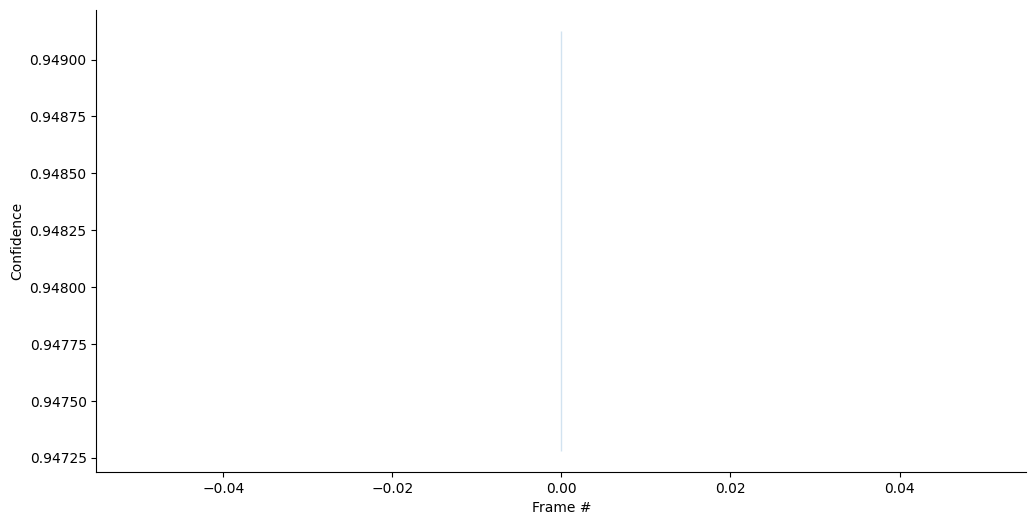

Average Confidence: 94.82 %


In [10]:
#check confs across frames
# these should all be above 0.7!
plt.figure(figsize=(12, 6))    # 12" wide by 6" tall
sns.lineplot(data = detections, x = 'frame', y = 'conf')
plt.ylabel('Confidence')
plt.xlabel('Frame #')
sns.despine()
plt.show()

# Average prediction conf 
# Should be close to 90%!
average_conf = detections['conf'].mean()*100
print(f"Average Confidence: {average_conf:.2f} %")


### lets also check the metrics on the model speeds

ValueError: Could not interpret value `speed_preprocess_ms` for `x`. An entry with this name does not appear in `data`.

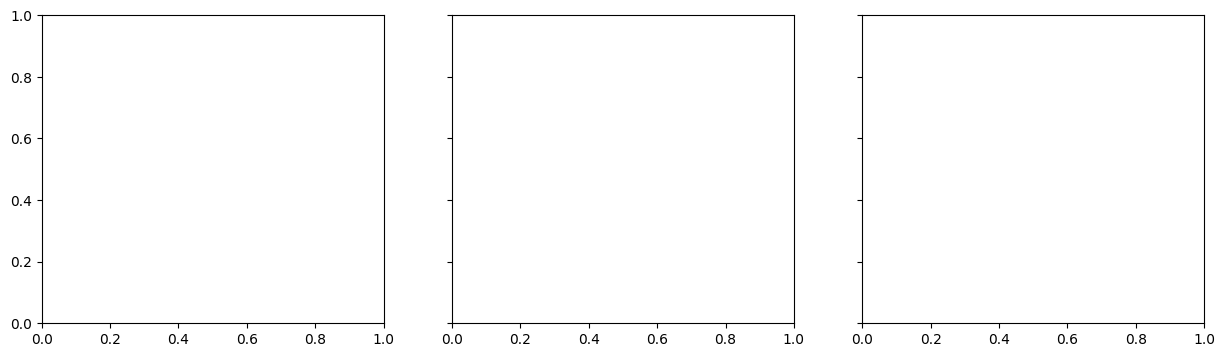

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
speed_columns = [
    ("speed_preprocess_ms", "Preprocess"),
    ("speed_inference_ms", "Inference"),
    ("speed_postprocess_ms", "Postprocess")
]

stage_totals_ms = {}

for ax, (col, label) in zip(axes, speed_columns):
    sns.boxplot(data=detections, x=col, ax=ax, orient="h", color="#4c72b0")
    mean_val = detections[col].mean()
    median_val = detections[col].median()
    total_val = detections[col].sum()
    stage_totals_ms[label] = total_val
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1, label=f"Mean = {mean_val:.2f} ms")
    ax.axvline(median_val, color="green", linestyle=":", linewidth=1, label=f"Median = {median_val:.2f} ms")
    ax.set_title(f"{label} Time per Frame")
    ax.set_xlabel("Milliseconds per frame")
    ax.set_ylabel("")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

total_processing_ms = sum(stage_totals_ms.values())
video_frames = len(detections)
video_duration_s = video_frames / FPS if FPS else float("nan")
processing_time_s = total_processing_ms / 1000
effective_fps = video_frames / processing_time_s if processing_time_s > 0 else float("nan")
speedup_vs_realtime = video_duration_s / processing_time_s if processing_time_s > 0 else float("nan")

print("Total processing time by stage:")
for stage, total in stage_totals_ms.items():
    print(f"  {stage}: {total/1000:.2f} seconds ({total:.0f} ms)")
print(f"Overall processing time: {processing_time_s:.2f} seconds ({total_processing_ms:.0f} ms)")

print("Video analysis summary:")
print(f"  Total frames processed: {video_frames}")
print(f"  Video duration (real time): {video_duration_s:.2f} seconds")
print(f"  Effective processing FPS: {effective_fps:.2f} frames/sec")
print(f"  Speedup vs real-time: {speedup_vs_realtime:.2f}x")



### Generate Features

In [12]:
# Ensure one detection per frame in temporal order
detections = detections.sort_values(['frame', 'conf'], ascending=[True, False])
detections = detections.drop_duplicates(subset='frame', keep='first').reset_index(drop=True)

# Differences in the smoothed center coordinates
detections['dx'] = detections['cx_euro'].diff()
detections['dy'] = detections['cy_euro'].diff()

# Frame and time deltas (default to video FPS when timestamps repeat or are missing)
frame_delta = detections['frame'].diff()
detections['dt_frames'] = frame_delta.fillna(1)
default_dt = 1.0 / FPS if FPS else np.nan
time_delta = detections['ts_s'].diff()
dt_seconds = time_delta.where(time_delta > 0, detections['dt_frames'] * default_dt)
detections['dt_seconds'] = dt_seconds.fillna(detections['dt_frames'] * default_dt)

# Velocity, distance, and heading in pixels
detections['vx'] = detections['dx'] / detections['dt_seconds']
detections['vy'] = detections['dy'] / detections['dt_seconds']
detections['distance'] = np.sqrt(detections['dx']**2 + detections['dy']**2)
detections['speed_px_per_frame'] = detections['distance'] / detections['dt_frames']
detections['speed_px_per_sec'] = detections['distance'] / detections['dt_seconds']
detections['acceleration'] = detections['speed_px_per_sec'].diff() / detections['dt_seconds']
detections['heading'] = np.arctan2(detections['vy'], detections['vx'])

# Bounding-box descriptors (already in pixels)
detections['width'] = detections['w']
detections['height'] = detections['h']
detections['aspect_ratio'] = detections['width'] / detections['height']
detections['area'] = detections['width'] * detections['height']
detections['area_change'] = detections['area'].diff().fillna(0)
detections['aspect_change'] = detections['aspect_ratio'].diff().fillna(0)

# Metric conversions (fallback to NaN if scale not defined)
if 'mm_per_pixel' not in globals():
    mm_per_pixel = np.nan

detections['distance_mm'] = detections['distance'] * mm_per_pixel
detections['speed_mm_per_sec'] = detections['speed_px_per_sec'] * mm_per_pixel
detections['vx_mm'] = detections['vx'] * mm_per_pixel
detections['vy_mm'] = detections['vy'] * mm_per_pixel
detections['acceleration_mm_per_sec2'] = detections['acceleration'] * mm_per_pixel
detections['width_mm'] = detections['width'] * mm_per_pixel
detections['height_mm'] = detections['height'] * mm_per_pixel
detections['area_mm2'] = detections['area'] * (mm_per_pixel ** 2)

# Cumulative path length and heading in degrees
detections['cumulative_distance_mm'] = detections['distance_mm'].cumsum()
detections['heading_deg'] = (-np.degrees(detections['heading']) + 360) % 360

detections.head()



,frame,ts_us,stream_id,source,obj_id,class_id,class_label,conf,x,y,...,distance_mm,speed_mm_per_sec,vx_mm,vy_mm,acceleration_mm_per_sec2,width_mm,height_mm,area_mm2,cumulative_distance_mm,heading_deg
0,0,1771940412180524,0,cam0,18446744073709551615,0,mouse,0.979004,374.625,146.25,...,NaN,NaN,NaN,NaN,NaN,14.909247,36.972976,551.239229,NaN,NaN


### Distance Traveled

In [ ]:
plt.figure(figsize=(16, 6))
sns.lineplot(data = detections, x = 'frame', y = 'distance_mm')
plt.ylabel('Distance Traveled (mm)')
plt.xlabel('Frame #')
sns.despine()
plt.show()

# Total distance traveled
total_distance_mm = detections['distance_mm'].sum()
print(f"Total distance traveled: {total_distance_mm:.2f} mm")

# Total distance traveled
total_distance_m = total_distance_mm/1000
print(f"Total distance traveled: {total_distance_m:.2f} meters")


### Plot velocity components and speed 

In [ ]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=detections, x='frame', y='vx_mm', label='vx (horizontal)')
sns.lineplot(data=detections, x='frame', y='vy_mm', label='vy (vertical)')
plt.xlabel('Frame #')
plt.ylabel('Velocity Component (mm/sec)')
sns.despine()
plt.legend()
plt.show()



In [ ]:
plt.figure(figsize=(16, 6))
sns.lineplot(data = detections, x = 'frame', y = 'speed_mm_per_sec', linewidth = 0.5)
plt.ylabel('Speed (mm/second)')
plt.xlabel('Frame #')
sns.despine()
plt.show()

# Total distance traveled
average_speed = detections['speed_mm_per_sec'].mean()
print(f"Average speed: {average_speed:.2f} mm/second")



### Plot Acceleration

In [ ]:
plt.figure(figsize=(16, 6))
sns.lineplot(data = detections, x = 'frame', y = 'acceleration_mm_per_sec2', linewidth = 0.5)
plt.ylabel('Acceleration (mm/second²)')
plt.xlabel('Frame #')
sns.despine()
plt.show()

# Total distance traveled
average_accel = detections['acceleration_mm_per_sec2'].mean()
print(f"Average acceleration: {average_accel:.2f} mm/second²")



#### Compute heading (direction of velocity vectors across the whole task)

In [ ]:
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

# Plot a polar histogram of heading angles
ax.hist(detections['heading'], bins=60, density=True)

ax.set_theta_zero_location('E')  # 0 at the top
ax.set_theta_direction(1)       # clockwise
ax.set_title('Heading Direction Distribution', y=1.1)

# Add grid for readability
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

plt.show()


### Plot trajectories

In [ ]:
# Load the first frame from video
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if not ret:
    raise ValueError("Failed to load frame from video")

# Convert BGR (OpenCV) to RGB for matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Plot the background and trajectory
plt.figure(figsize=(10, 8))
plt.imshow(frame_rgb)
plt.scatter(detections['cx_euro'], detections['cy_euro'], c=detections['frame'], cmap='viridis', s=1)

plt.title('Trajectory Overlay on Video Frame')
plt.xlabel('X Position (pixels)')
plt.ylabel('Y Position (pixels)')
plt.axis('equal')
plt.gca().invert_yaxis()  # OpenCV origin is top-left
plt.colorbar(label='Frame #')

plt.tight_layout()
plt.show()


### Plot Heatmaps

In [ ]:
# Step 1: Load background frame
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if not ret:
    raise ValueError("Failed to read a frame from video.")

# Convert to RGB for matplotlib display
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
frame_height, frame_width = frame.shape[:2]

# Step 2: Create 2D histogram of occupancy
heatmap, xedges, yedges = np.histogram2d(detections['cx_euro'], detections['cy_euro'], bins=50, range=[[0, frame_width], [0, frame_height]])

# Transpose to match image orientation
heatmap = heatmap.T

# Step 3: Plot the frame and overlay heatmap
plt.figure(figsize=(10, 8))
plt.imshow(frame_rgb)  # Background frame
plt.imshow(
    heatmap,
    cmap='jet',
    alpha=0.7,
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    origin='lower',
    interpolation='bilinear'
)

plt.title("Occupancy Heatmap Over Frame")
plt.xlabel("X Position (pixels)")
plt.ylabel("Y Position (pixels)")
plt.gca().invert_yaxis()  # Match OpenCV coordinate system
plt.colorbar(label="Occupancy Count")
plt.tight_layout()
plt.show()



### ROIS

In [ ]:
import cv2
import numpy as np
from matplotlib.path import Path

# --- Step 1: Load first frame from video ---
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if not ret:
    raise ValueError("Could not read a frame from the video.")

# --- Step 2: Initialize drawing environment ---
frame_overlay = frame.copy()
roi_defs = []
drawing = False
start_pt = (-1, -1)
current_pt = (-1, -1)

def draw_all_rois(img):
    for roi in roi_defs:
        pts = np.array(roi['points'], dtype=np.int32)
        cv2.polylines(img, [pts], isClosed=True, color=(255, 0, 0), thickness=2)
        cv2.putText(img, roi['name'], pts[0], cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

def mouse_callback(event, x, y, flags, param):
    global start_pt, current_pt, drawing, frame_overlay

    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        start_pt = (x, y)
        current_pt = (x, y)

    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        current_pt = (x, y)

    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        current_pt = (x, y)
        x1, y1 = start_pt
        x2, y2 = current_pt
        xmin, xmax = sorted([x1, x2])
        ymin, ymax = sorted([y1, y2])
        rect_pts = [(xmin, ymin), (xmax, ymin), (xmax, ymax), (xmin, ymax)]

        name = input("Enter a name for this ROI: ")
        roi_defs.append({
            'name': name,
            'points': rect_pts,
            'path': Path(rect_pts)
        })
        print(f"ROI '{name}' saved.")

        frame_overlay = frame.copy()
        draw_all_rois(frame_overlay)

# --- Step 3: Launch window for interactive drawing ---
cv2.namedWindow("Draw Rectangular ROIs")
cv2.setMouseCallback("Draw Rectangular ROIs", mouse_callback)

print("🖱 Click and drag to draw a rectangle ROI.\nPress ESC when done.")

while True:
    display_frame = frame_overlay.copy()
    if drawing:
        cv2.rectangle(display_frame, start_pt, current_pt, (0, 255, 0), 2)
    cv2.imshow("Draw Rectangular ROIs", display_frame)
    if cv2.waitKey(1) & 0xFF == 27:  # ESC
        break

cv2.destroyAllWindows()
_ = cv2.waitKey(1)



In [ ]:

# Helper utilities for ROI analysis
from typing import Iterable

def _require_rois(rois: Iterable) -> None:
    if not rois:
        raise RuntimeError('No ROIs defined. Run the ROI drawing cell to create ROI polygons.')


def assign_roi_labels(df: pd.DataFrame, rois: Iterable, x_col: str = 'cx_euro', y_col: str = 'cy_euro') -> pd.Series:
    """Return an ROI label for each row using the provided polygons."""
    _require_rois(rois)

    def locate(row) -> str:
        x = row.get(x_col)
        y = row.get(y_col)
        if pd.isna(x) or pd.isna(y):
            return np.nan
        for roi in rois:
            if roi['path'].contains_point((x, y)):
                return roi['name']
        return np.nan

    return df.apply(locate, axis=1)

def require_roi_labels(df: pd.DataFrame) -> None:
    if 'roi_label' not in df.columns:
        raise RuntimeError('ROI labels are missing. Run the ROI assignment cell first.')


def summarize_roi_time(df: pd.DataFrame, fps: float) -> pd.Series:
    require_roi_labels(df)
    counts = df['roi_label'].value_counts()
    return (counts / fps).sort_values(ascending=False)


def roi_transition_matrix(df: pd.DataFrame) -> pd.DataFrame:
    require_roi_labels(df)
    sequence = df['roi_label']
    transitions = pd.DataFrame({'from': sequence.shift(1), 'to': sequence})
    transitions = transitions[transitions['from'] != transitions['to']]
    return transitions.value_counts().unstack(fill_value=0)



In [ ]:

# Assign ROI labels to each detection using smoothed center coordinates
detections['roi_label'] = assign_roi_labels(detections, roi_defs)
display_cols = ['frame', 'ts_s', 'cx_euro', 'cy_euro', 'roi_label']
detections[display_cols].head()



In [ ]:

# Total time spent per ROI in seconds
roi_time_sec = summarize_roi_time(detections, FPS)

plt.figure(figsize=(8, 5))
sns.barplot(x=roi_time_sec.index, y=roi_time_sec.values, hue=roi_time_sec.index, palette='Set2', legend=False)
plt.title('Time Spent in Each ROI (Seconds)')
plt.ylabel('Time (s)')
plt.xlabel('ROI')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()



In [ ]:

# Speed distribution by ROI
require_roi_labels(detections)
roi_speed_means = detections.groupby('roi_label')['speed_mm_per_sec'].mean().sort_values(ascending=False)
sorted_roi_labels = roi_speed_means.index.tolist()

plt.figure(figsize=(10, 6))
sns.pointplot(
    data=detections.dropna(subset=['roi_label']),
    x='roi_label',
    y='speed_mm_per_sec',
    order=sorted_roi_labels,
    linestyle='none',
    errorbar='se',
    hue='roi_label',
    palette='Set1'
)

sns.stripplot(
    data=detections.dropna(subset=['roi_label']),
    x='roi_label',
    y='speed_mm_per_sec',
    order=sorted_roi_labels,
    hue='roi_label',
    jitter=True,
    alpha=0.7,
    size=1,
    palette='Set1'
)

plt.title('Speed by ROI')
plt.xlabel('ROI')
plt.ylabel('Speed (mm/s)')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()



In [ ]:

# ROI transition matrix
transition_counts = roi_transition_matrix(detections.dropna(subset=['roi_label']))

plt.figure(figsize=(8, 6))
sns.heatmap(
    transition_counts,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    cbar=False
)
plt.title('ROI Transition Matrix (Full Directional View)')
plt.xlabel('To ROI')
plt.ylabel('From ROI')
plt.tight_layout()
plt.show()



In [ ]:

# ROI occupancy timeline
require_roi_labels(detections)
filtered = detections.dropna(subset=['roi_label'])
unique_rois = sorted(filtered['roi_label'].unique())
roi_to_y = {roi: i for i, roi in enumerate(unique_rois)}

filtered = filtered.assign(roi_y=filtered['roi_label'].map(roi_to_y))

plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=filtered,
    x='ts_s',
    y='roi_y',
    hue='roi_label',
    palette='Set2',
    s=8,
    linewidth=0
)

plt.yticks(ticks=list(roi_to_y.values()), labels=list(roi_to_y.keys()))
plt.xlabel('Time (seconds)')
plt.ylabel('ROI')
plt.title('ROI Occupancy Timeline (Each ROI on Separate Line)')
plt.legend(title='ROI', bbox_to_anchor=(1.01, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()



### Make an annotated Video with annotation overlays

In [ ]:
# Render an annotated video using the smoothed detections dataframe
if 'roi_label' not in detections.columns:
    print('ROI labels not found; annotations will omit ROI text.')

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise IOError("Cannot open video")

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('annotated_output.mp4', fourcc, fps if fps > 0 else FPS, (width, height))

frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_idx >= len(detections):
        break

    row = detections.iloc[frame_idx]
    draw_annotations = True

    bbox_vals = [row.get('x1'), row.get('y1'), row.get('x2'), row.get('y2')]
    if any(pd.isna(v) for v in bbox_vals):
        draw_annotations = False
    else:
        x1, y1, x2, y2 = [int(round(v)) for v in bbox_vals]

    cx = row.get('cx_euro')
    cy = row.get('cy_euro')
    if pd.isna(cx) or pd.isna(cy):
        cx = row.get('cx')
        cy = row.get('cy')
    center_point = None if pd.isna(cx) or pd.isna(cy) else (int(round(cx)), int(round(cy)))

    text = f"Frame: {int(row['frame'])}"
    if not pd.isna(row.get('cumulative_distance_mm')):
        text += f" | Distance: {row['cumulative_distance_mm']:.1f} mm"

    speed_val = row.get('speed_mm_per_sec')
    heading_val = row.get('heading_deg')
    roi_label = row.get('roi_label') if 'roi_label' in detections.columns else None
    text2_parts = []
    if not pd.isna(speed_val):
        text2_parts.append(f"Speed: {speed_val:.1f} mm/s")
    if not pd.isna(heading_val):
        text2_parts.append(f"Heading: {heading_val:.0f}°")
    if roi_label is not None and not pd.isna(roi_label):
        text2_parts.append(f"ROI: {roi_label}")
    text2 = " | ".join(text2_parts)

    if draw_annotations:
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
        if center_point:
            cv2.circle(frame, center_point, 4, (0, 0, 255), -1)
        cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        if text2:
            cv2.putText(frame, text2, (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()

